## Fine tuning e classificazione con un modello Transformer

Questo notebook è l'unico realizzato con google colab così da poter sfruttare la gpu che mette a disposizione. 

I risultati presentati in questo notebook sono quelli di bert-base-cased. Per osservare il comportamento di distilbert-base-cased levare i commenti dalle righe relative e rerunnare.

In [ ]:
! pip install datasets
! pip install transformers

# Sono stata costretta ad installare questa versione di numpy per incompatibilità con hugging face e datasets
! pip install numpy==1.24.4 --force-reinstall


In [ ]:
# Installo versione corrente di evaluate
! pip install evaluate --upgrade --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.4/515.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from google.colab import drive

import numpy as np
import pandas as pd
import datasets
import evaluate
import seaborn as sns

from transformers import AutoTokenizer, DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

## Caricamento dei dati

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive')
import utils_svm

In [ ]:
folder_path = '/content/drive/MyDrive'
dictionary = '/content/drive/MyDrive/data.json'

data = utils_svm.load_data(dictionary)

In [ ]:
# Divido i dati in training, validation e test sulla base del dizionario
# Estraggo la label 'author'
train_data = []
val_data = []
test_data = []

labels = []

for doc_id in data:

  label = data[doc_id]['author']

  if not label in labels:
    labels.append(label)

  if data[doc_id]['split'] == "train":
    train_data.append(data[doc_id])
  elif data[doc_id]['split'] == 'val':
    val_data.append(data[doc_id])
  else:
    test_data.append(data[doc_id])

In [ ]:
# Creo un dizionario di mapping fra le labels come stringhe e le label numeriche
str_to_int = {label: num for num, label in enumerate(labels)}

# Mappo le etichette da stringhe a numeri
def encode_labels(example):
    return {
        "text": example["text"],
        "labels": str_to_int[example["author"]]
    }

# Divido train, val, test
train = datasets.Dataset.from_list([encode_labels(d) for d in train_data])
val   = datasets.Dataset.from_list([encode_labels(d) for d in val_data])
test  = datasets.Dataset.from_list([encode_labels(d) for d in test_data])

In [ ]:
# Visualizzo i dati per controllarne la forma
print(train)
print()
print("Esempio di testo:", train['text'][2])
print()
print("Esempio di label:", train['labels'][2])
print()

print("Dimensione dei training, development and test sets:")
print("Train:", train.shape)
print("Dev:", val.shape)
print("Test:", test.shape)

Dataset({
    features: ['text', 'labels'],
    num_rows: 3600
})

Esempio di testo: “Dorothea, dear, if you don’t mind—if you are not very busy—suppose we looked at mamma’s jewels to-day, and divided them? It is exactly six months to-day since uncle gave them to you, and you have not looked at them yet.”

Esempio di label: 0

Dimensione dei training, development and test sets:
Train: (3600, 2)
Dev: (1500, 2)
Test: (2094, 2)


## Caricamento del modello

In [ ]:
# Nome del modello scelto
model_name = "bert-base-cased"
#model_name = "distilbert-base-cased"

In [ ]:
# Caricamento modello e tokenizzatore
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels))
tokenizer = AutoTokenizer.from_pretrained(model_name)

#model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=len(labels))
#tokenizer = DistilBertTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

## Preprocessing dei dati

In [ ]:
# Tokenizzo i dati
def tokenize(batch):
    tokens = tokenizer(batch['text'], padding=True, truncation=True, max_length=512)
    tokens['labels'] = batch['labels']  # già numerici
    return tokens

train = train.map(tokenize, batched=True)
val = val.map(tokenize, batched=True)
test = test.map(tokenize, batched=True)

# Trasformo i dati in array numpy
train.set_format('numpy', columns=['input_ids', 'attention_mask', 'labels'])
val.set_format('numpy', columns=['input_ids', 'attention_mask', 'labels'])
test.set_format('numpy', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2094 [00:00<?, ? examples/s]

## Allenamento

In [ ]:
# Setting degli iperparametri

num_epochs = 6

training_args = TrainingArguments(
    f"{model_name}-finetuned",
    eval_strategy = "epoch",
    logging_strategy="epoch",
    save_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

In [ ]:
# Funzione per il calcolo della metrica di valutazione f1 score
def compute_metrics(eval_pred):
  f1_metric = evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)

  return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

In [ ]:
# Setto il modello e lo alleno
trainer = Trainer(
    model,
    training_args,
    train_dataset=train,
    eval_dataset=val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.save_model("/content/drive/My Drive/FINETUNED_MODEL")
# Salvataggio per distilbert
#trainer.save_model("/content/drive/My Drive/distilbert_FINETUNE")

/tmp/ipython-input-15-3670967361.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: l-rotellini (l-rotellini-universit-di-pisa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,F1
1,0.276500,1.068428,0.777596
2,0.035800,0.879918,0.840625
3,0.008500,1.401222,0.799303


Epoch,Training Loss,Validation Loss,F1
1,0.276500,1.068428,0.777596
2,0.035800,0.879918,0.840625
3,0.008500,1.401222,0.799303
4,0.001900,1.033627,0.834999
5,0.000400,1.181970,0.837675
6,0.000100,1.175445,0.835318


## Evaluation

/tmp/ipython-input-16-2946980306.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, log_df], ignore_index=True)


<Axes: xlabel='Epoch', ylabel='Loss'>

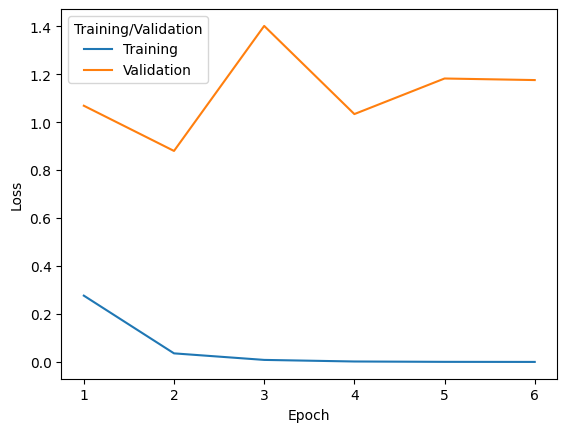

In [ ]:
# Salvo la history del modello per plottare le curve di training e validation loss
log_history = trainer.state.log_history

# Creo dataframe pandas per le loss di training/evaluation da usare per realizzare la curva di apprendimento
df = pd.DataFrame(columns=["Epoch", "Loss", "Training/Validation"])

for log_data in log_history:
  epoch = int(log_data["epoch"])
  if "loss" in log_data.keys():
    loss = log_data["loss"]

    log_df = pd.DataFrame({"Epoch": [epoch], "Loss": [loss], "Training/Validation": ["Training"]})
    df = pd.concat([df, log_df], ignore_index=True)
  if "eval_loss" in log_data.keys():
    loss = log_data["eval_loss"]
    log_df = pd.DataFrame({"Epoch": [epoch], "Loss": [loss], "Training/Validation": ["Validation"]})
    df = pd.concat([df, log_df], ignore_index=True)

# Plotto la loss
sns.lineplot(data=df, x="Epoch", y="Loss", hue="Training/Validation")

In [ ]:
# Predizione sulle istanze di test
output_predictions = trainer.predict(test)
print(output_predictions)

PredictionOutput(predictions=array([[ 5.0988975, -2.5671537, -2.5423346],
       [ 5.3776693, -3.57446  , -1.5433017],
       [-3.0294037,  5.7883406, -3.5366244],
       ...,
       [-2.2684267, -2.7134743,  6.17244  ],
       [-2.7073233, -2.7990522,  6.5548053],
       [-2.9717345, -2.8167932,  6.7033043]],
      shape=(2094, 3), dtype=float32), label_ids=array([0, 0, 0, ..., 2, 2, 2], shape=(2094,)), metrics={'test_loss': 0.9158585071563721, 'test_f1': 0.8590510686910187, 'test_runtime': 19.7407, 'test_samples_per_second': 106.075, 'test_steps_per_second': 13.272})


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83       698
           1       0.91      0.69      0.79       698
           2       0.96      0.96      0.96       698

    accuracy                           0.86      2094
   macro avg       0.87      0.86      0.86      2094
weighted avg       0.87      0.86      0.86      2094


Confusion Matrix:


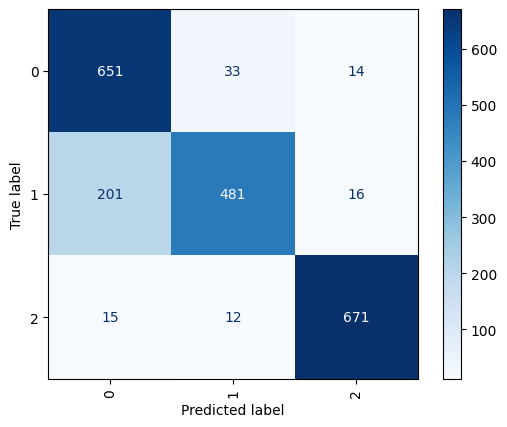

In [ ]:
# Classification report e confusion matrix
y_test = test["labels"].tolist()
y_pred = np.argmax(output_predictions.predictions, axis=1)

report = classification_report(y_test, y_pred)
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation='vertical', cmap='Blues')

print("Classification Report:")
print(report)
print()

print("Confusion Matrix:")
print(cm)